# Can LLMs Reason? A Hands-On Approach

This tutorial is adapted by means of vibe-coding from [Tyler Shoemaker's Digital Theory Lab Interpretability Workshop from Summer 2026](https://digitaltheorylab.github.io/2026_interpretability-reader/), with permission. Faults in the code and the concepts are mine.


#1. Chain-of-Thought Reasoning





# 2. Setting Up
#Install packages
#Imports
#Load a reasoning model
#Reproducibility

In [1]:
# Colab will very likely have all these installed already, so we run this just as a precaution
!pip -q install \
    transformers \
    accelerate \
    bitsandbytes \
    sentencepiece \
    scipy \
    scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 12.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.stats import median_abs_deviation

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

In [4]:
SEED = 5167

np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [29]:
checkpoint = "Qwen/Qwen3-0.6B" #"Qwen/Qwen2.5-1.5B-Instruct"

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # Runtime -> Change runtime type -> TPU
print(device)

cuda


In [31]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

if device == "cuda":
    bnb = BitsAndBytesConfig(load_in_4bit=True)
    model = AutoModelForCausalLM.from_pretrained(
        checkpoint,
        device_map="auto",
        quantization_config=bnb,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(checkpoint)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear4bit(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
 

#3. Generating a Reasoning Trace

a. write a prompt

In [32]:
prompt = (
    "A store has 40 apples. "
    "In the morning it sells one third of them. "
    "In the afternoon a delivery adds 18 apples. "
    "Then 25% of the apples are sold. "

)

b. generate from instruct and thinking separately

In [33]:
messages = [
    {
        "role": "user",
        "content": prompt,
    }
]

chat = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(chat, return_tensors="pt").to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = output[0][inputs["input_ids"].shape[-1]:]

pieces = []

for tid in generated.tolist():
    token = tokenizer.convert_ids_to_tokens(tid)

    # Show control tokens literally
    if token.startswith("<") and token.endswith(">"):
        pieces.append(token)

    # Otherwise decode normally
    else:
        pieces.append(
            tokenizer.decode(
                [tid],
                skip_special_tokens=False,
                clean_up_tokenization_spaces=False,
            )
        )

print("".join(pieces))

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.

First, let's break down the problem step by step.

Starting with the initial 40 apples.

In the morning, they sell one third of them. So, selling one third means


In [35]:
full = output[0]

pieces = []

for tid in full.tolist():

    tok = tokenizer.convert_ids_to_tokens(tid)

    if tok.startswith("<") and tok.endswith(">"):
        pieces.append(tok)
    else:
        pieces.append(
            tokenizer.decode([tid], skip_special_tokens=False)
        )

print("".join(pieces))

<|im_start|>user
A store has 40 apples. In the morning it sells one third of them. In the afternoon a delivery adds 18 apples. Then 25% of the apples are sold. <|im_end|>
<|im_start|>assistant
put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.

First, let's break down the problem step by step.

Starting with the initial 40 apples.

In the morning, they sell one third of them. So, selling one third means


Extracting the reasoning trace

In [36]:
think_open = tokenizer.convert_tokens_to_ids("<think>")
think_close = tokenizer.convert_tokens_to_ids("</think>")

In [37]:
sequence = output[0]
generated = sequence[inputs["input_ids"].shape[-1]:]
ids = generated.tolist()

start = ids.index(think_open) if think_open in ids else 0

end = (
    ids.index(think_close)
    if think_close in ids
    else len(ids)
)

cot_ids = generated[start:end]
print("=" * 80)
print("REASONING TRACE")
print("=" * 80)
print()

print(tokenizer.decode(cot_ids, skip_special_tokens=False))

REASONING TRACE

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.

First, let's break down the problem step by step.

Starting with the initial 40 apples.

In the morning, they sell one third of them. So, selling one third means


c. Recovering hidden states

so far we have treated the model as a text generator; now we want to look at it as a neural net; every generation run, every prompt, recontextualizes each node in the net, or gives news values to the distributions; now we will look at these by layer

In [38]:
with torch.no_grad():
    outputs = model(
        sequence.unsqueeze(0),
        output_hidden_states=True,
        use_cache=False,
    )

In [39]:
hidden_states = outputs.hidden_states

NUM_LAYERS = len(hidden_states)

LAYER = NUM_LAYERS // 2

print(f"Using layer {LAYER} of {NUM_LAYERS}")

Using layer 14 of 29


In [40]:
trajectory = hidden_states[LAYER][0].float().cpu()

In [41]:
prompt_length = inputs["input_ids"].shape[-1]

cot_slice = slice(
    prompt_length + start,
    prompt_length + end,
)

hidden = trajectory[cot_slice]

cot_ids = cot_ids[: len(hidden)]

In [42]:
text = tokenizer.decode(cot_ids)
print(text)

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.

First, let's break down the problem step by step.

Starting with the initial 40 apples.

In the morning, they sell one third of them. So, selling one third means


# 4. Monitoring Chain-of-thought
can we use exploratory statistical analysis of these hidden states to check when the model might be swerving away from our expected goals?

In [43]:
print(hidden.shape)

torch.Size([128, 1024])


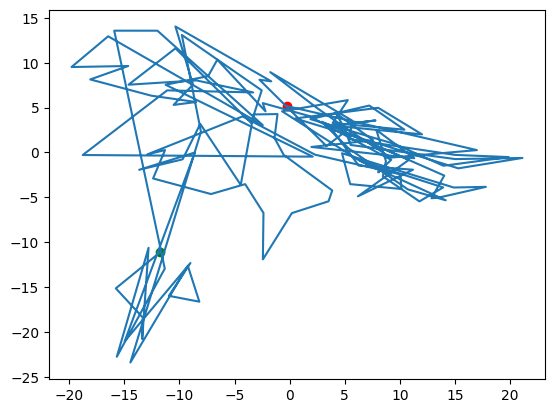

In [44]:
# using principal component analysis, we can graph the hidden-state "path" with twists and turns

from sklearn.decomposition import PCA

xy = PCA(n_components=2).fit_transform(hidden.numpy())

plt.plot(xy[:,0], xy[:,1])
plt.scatter(xy[0,0], xy[0,1], c="green")
plt.scatter(xy[-1,0], xy[-1,1], c="red")

In [45]:
# but remember, even generating repeatedly up to a given step, say 20:40:60 and
# so on, gives us continuous next-token prediction of a smooth text in the trace

for i in range(0, len(cot_ids), 20):

    print("-"*60)

    print(tokenizer.decode(cot_ids[:i]))

------------------------------------------------------------

------------------------------------------------------------
put your answer in the box
Okay, let's try to figure out this problem. So,
------------------------------------------------------------
put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then
------------------------------------------------------------
put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples
------------------------------------------------------------
put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking 

In [46]:
def boundary_score(hidden, window):
    """Estimate how sharply the model changes direction within each `window`."""

    n = hidden.shape[0]
    scores = torch.zeros(n)

    for i in range(n):

        left = hidden[max(0, i-window):i]
        right = hidden[i:min(n, i+window)]

        if len(left) == 0 or len(right) == 0:
            continue

        left_mean = left.mean(0)
        right_mean = right.mean(0)

        scores[i] = 1 - F.cosine_similarity(left_mean, right_mean, dim=0)

    return scores

WINDOW = 5
scores = boundary_score(hidden, WINDOW)

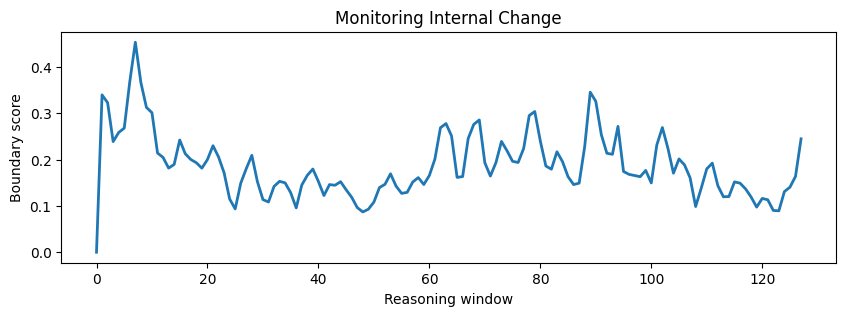

In [47]:
# now we plot the changes in direction over the layers

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(scores.numpy(), lw=2)

ax.set(
    xlabel="Reasoning window",
    ylabel="Boundary score",
    title="Monitoring Internal Change",
)

plt.show()

In [48]:
# compare the text - do the changes in direction match any intuitive sense of
# where the text might be deviating from expectations?

text = tokenizer.decode(cot_ids)
print(text)

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.

First, let's break down the problem step by step.

Starting with the initial 40 apples.

In the morning, they sell one third of them. So, selling one third means


In [50]:
# step through and INSPECT

STEP = 30

for i in range(STEP, len(cot_ids), STEP):

    print("="*70)

    print(f"Reasoning through token {i}")

    print()

    print(tokenizer.decode(cot_ids[:i]))

    print()

    print(f"Current boundary score: {scores[i]:.3f}")

    input("Press Enter...")


Reasoning through token 30

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the

Current boundary score: 0.114
Press Enter...
Reasoning through token 60

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples

Current boundary score: 0.166
Press Enter...
Reasoning through token 90

put your answer in the box
Okay, let's try to figure out this problem. So, the store has 40 apples. In the morning, they sell one third of them. Then in the afternoon, a delivery adds 18 apples. Then 25% of the apples are sold. The question is asking for the total number of apples remaining after all these events. And we need to put the answer in a box.



Current boundary score: 0.326
Press Enter...
Reasoning through token 120

put your answer in the box
Okay, let's try to figure out this prob

In [51]:
# run peak detection. these should tell us where the trace breaks into "natural"
# chunks using the dissimilarity scores we computed above

peaks, _ = find_peaks(scores.numpy(), height=np.percentile(scores.numpy(), 90))

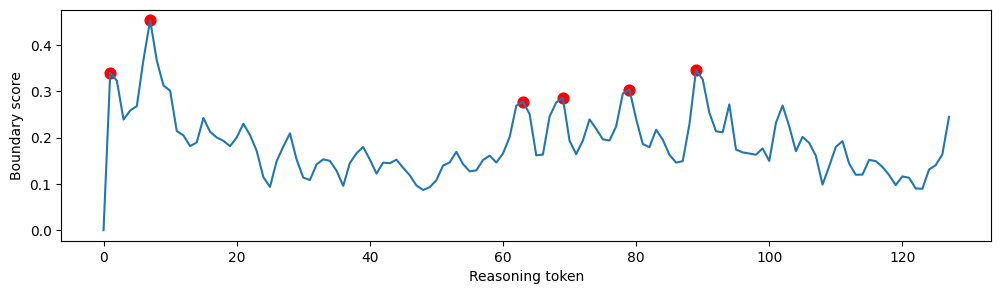

In [52]:
# plot peaks for DANGER

plt.figure(figsize=(12,3))

plt.plot(scores)

plt.scatter(
    peaks,
    scores[peaks],
    color="red",
    s=60,
)

plt.xlabel("Reasoning token")
plt.ylabel("Boundary score")

plt.show()

In [53]:
for peak in peaks:

    left = tokenizer.decode(
        cot_ids[max(0, peak-WINDOW):peak]
    )

    right = tokenizer.decode(
        cot_ids[peak:min(len(cot_ids), peak+WINDOW)]
    )

    print("=" * 80)
    print(f"Boundary at token {peak}")
    print(f"Score = {scores[peak]:.3f}")
    print("=" * 80)

    print("\nLEFT WINDOW\n")
    print(left)

    print("\nRIGHT WINDOW\n")
    print(right)

    print()

Boundary at token 1
Score = 0.340

LEFT WINDOW

put

RIGHT WINDOW

 your answer in the box

Boundary at token 7
Score = 0.454

LEFT WINDOW

 answer in the box


RIGHT WINDOW

Okay, let's try

Boundary at token 63
Score = 0.278

LEFT WINDOW

 the apples are sold.

RIGHT WINDOW

 The question is asking for

Boundary at token 69
Score = 0.286

LEFT WINDOW

 question is asking for the

RIGHT WINDOW

 total number of apples remaining

Boundary at token 79
Score = 0.304

LEFT WINDOW

 after all these events.

RIGHT WINDOW

 And we need to put

Boundary at token 89
Score = 0.346

LEFT WINDOW

 the answer in a box

RIGHT WINDOW

.

First, let's



# 5. Using Monitoring To Understand What Is Distinctive to Chain-of-Thought

expand the scope of prompt tasks -- ask: what is a task? where does it live in the model?

In [58]:
PROMPTS = {
    "Poetry":
    "Write me a poem in iambic pentameter. Think step by step.",

    "Biology":
    "Explain why antibiotic resistance evolves. Think step by step.",

    "Cybersecurity":
    "Explain, at a high level, how defenders detect phishing campaigns and why those signals can fail. Think step by step.",
}

In [59]:
def get_reasoning_trajectory(prompt, max_new_tokens=128):

    messages = [
        {
            "role": "user",
            "content": prompt,
        }
    ]

    chat = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )

    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    # Generate text
    sequence = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=True,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
    )[0]

    generated_ids = sequence[inputs["input_ids"].shape[-1]:]

    # Find reasoning trace
    think_open = tokenizer.convert_tokens_to_ids("<think>")
    think_close = tokenizer.convert_tokens_to_ids("</think>")

    ids = generated_ids.tolist()

    start = ids.index(think_open) if think_open in ids else 0
    end = ids.index(think_close) if think_close in ids else len(ids)

    cot_ids = generated_ids[start:end]

    # Recover hidden states
    with torch.no_grad():
        outputs = model(
            sequence.unsqueeze(0),
            output_hidden_states=True,
            use_cache=False,
        )

    hidden_states = outputs.hidden_states

    layer = len(hidden_states) // 2

    trajectory = hidden_states[layer][0].float().cpu()

    prompt_len = inputs["input_ids"].shape[-1]

    hidden = trajectory[
        prompt_len + start :
        prompt_len + end
    ]

    cot_ids = cot_ids[:len(hidden)]

    return {
        "hidden": hidden,
        "cot_ids": cot_ids,
        "outputs": outputs,
        "inputs": inputs,
        "start": start,
        "end": end,
    }

In [60]:
CACHE = {}

def get_cached(prompt):
    """Store/get a trajectory from a shared cache."""
    if prompt not in CACHE:
        CACHE[prompt] = get_reasoning_trajectory(prompt)

    return CACHE[prompt]

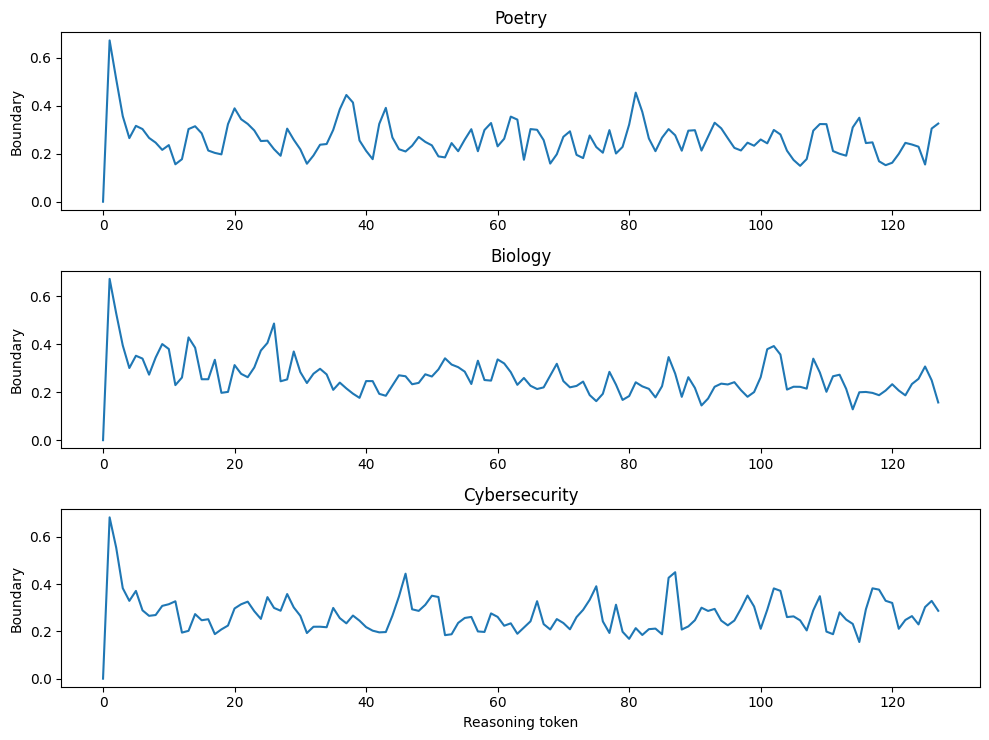

,Task,Tokens,Mean boundary,Maximum boundary,Std. dev.
0,Cybersecurity,128,0.271257,0.682609,0.079050
1,Poetry,128,0.261617,0.672831,0.079392
2,Biology,128,0.261612,0.671920,0.081227


In [61]:
WINDOW = 3

summary = []

fig, axes = plt.subplots(
    len(PROMPTS),
    1,
    figsize=(10, 2.5 * len(PROMPTS)),
)

if len(PROMPTS) == 1:
    axes = [axes]

for ax, (name, prompt) in zip(axes, PROMPTS.items()):

    traj = get_cached(prompt)

    hidden = traj["hidden"]
    cot_ids = traj["cot_ids"]

    scores = boundary_score(hidden, WINDOW)

    ax.plot(scores.numpy())

    ax.set_title(name)
    ax.set_ylabel("Boundary")

    summary.append({
        "Task": name,
        "Tokens": len(cot_ids),
        "Mean boundary": scores.mean().item(),
        "Maximum boundary": scores.max().item(),
        "Std. dev.": scores.std().item(),
    })

axes[-1].set_xlabel("Reasoning token")

plt.tight_layout()
plt.show()

summary = (
    pd.DataFrame(summary)
      .sort_values("Maximum boundary", ascending=False)
      .reset_index(drop=True)
)

summary

In [62]:
for i, row in summary.iterrows():
    print(f"{row['Task']}: max boundary = {row['Maximum boundary']:.3f}")

Cybersecurity: max boundary = 0.683
Poetry: max boundary = 0.673
Biology: max boundary = 0.672


In [63]:
def next_token_distribution(prefix_ids):
    """Get the total vocabulary distribution for each next-token slot."""
    with torch.no_grad():
        out = model(
            prefix_ids.unsqueeze(0).to(model.device)
        )

    logits = out.logits[0, -1]
    probs = logits.softmax(dim=-1).cpu()

    return probs

In [65]:
# how does the reasoning trace reshape the model's next-token distribution at inference time?

prompt = PROMPTS["Poetry"]

STEP = 20

traj = get_cached(prompt)

inputs = traj["inputs"]
cot_ids = traj["cot_ids"]

for i in range(STEP, len(cot_ids), STEP):

    prefix = torch.cat([
        inputs["input_ids"][0],
        cot_ids[:i]
    ])

    probs = next_token_distribution(prefix)

    values, indices = torch.topk(probs, 10)

    print("=" * 70)
    print(f"Reasoning through token {i}")
    print()
    print(tokenizer.decode(cot_ids[:i]))
    print()
    print("Most likely next tokens")

    for p, idx in zip(values, indices):
        print(
            f"{tokenizer.decode([idx.item()])!r:12s}"
            f"{p.item():.3f}"
        )

Reasoning through token 20

<think>
Okay, so the user wants me to write a poem in iambic pentameter

Most likely next tokens
'.'         0.930
','         0.067
' of'       0.001
' and'      0.001
' ('        0.000
' as'       0.000
' following'0.000
' with'     0.000
' from'     0.000
' using'    0.000
Reasoning through token 40

<think>
Okay, so the user wants me to write a poem in iambic pentameter. Let me think about how to approach this. First, I need to recall what iambic

Most likely next tokens
' pent'     1.000
' tet'      0.000
' Pent'     0.000
' pen'      0.000
' hex'      0.000
'pent'      0.000
' meter'    0.000
' quint'    0.000
' rhythm'   0.000
' dict'     0.000
Reasoning through token 60

<think>
Okay, so the user wants me to write a poem in iambic pentameter. Let me think about how to approach this. First, I need to recall what iambic pentameter is. It's a meter where each line has 10 syllables, with

Most likely next tokens
' an'       0.352
' a'        0.213
' '   

In [67]:
# now we look at that reshaping as short continuations of text at each step

TASK = "Poetry"

prompt = PROMPTS[TASK]
traj = get_cached(prompt)

inputs = traj["inputs"]
cot_ids = traj["cot_ids"]

STEP = 20

for i in range(STEP, len(cot_ids), STEP):

    prefix = torch.cat([
        inputs["input_ids"][0],
        cot_ids[:i]
    ]).unsqueeze(0).to(model.device)

    continuation = model.generate(
        prefix,
        max_new_tokens=10,
        do_sample=False,          # greedy for reproducibility
        temperature=None,
        pad_token_id=tokenizer.eos_token_id,
    )

    new_tokens = continuation[0][prefix.shape[-1]:]

    print("=" * 70)
    print(f"Reasoning through token {i}")
    print()
    print("Current reasoning:")
    print(tokenizer.decode(cot_ids[:i]))
    print()
    print("Most likely continuation:")
    print(tokenizer.decode(new_tokens))
    print()

Reasoning through token 20

Current reasoning:
<think>
Okay, so the user wants me to write a poem in iambic pentameter

Most likely continuation:
. Let me start by recalling what iambic

Reasoning through token 40

Current reasoning:
<think>
Okay, so the user wants me to write a poem in iambic pentameter. Let me think about how to approach this. First, I need to recall what iambic

Most likely continuation:
 pentameter is. It's a rhyme scheme

Reasoning through token 60

Current reasoning:
<think>
Okay, so the user wants me to write a poem in iambic pentameter. Let me think about how to approach this. First, I need to recall what iambic pentameter is. It's a meter where each line has 10 syllables, with

Most likely continuation:
 an unstressed syllable followed by an unstressed

Reasoning through token 80

Current reasoning:
<think>
Okay, so the user wants me to write a poem in iambic pentameter. Let me think about how to approach this. First, I need to recall what iambic pentameter is

# Try this with the different prompts above, and see if you can do it with the 40 apples problem
# we are asking: what does CoT do to Task-Completion?

In [69]:
# ------------------------------------------------------------
# Generate WITHOUT Chain-of-Thought
# ------------------------------------------------------------

TASK = "Poetry"

prompt = PROMPTS[TASK]

messages = [
    {
        "role": "user",
        "content": prompt,
    }
]

chat = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,    # <-- disable CoT
)

inputs = tokenizer(
    chat,
    return_tensors="pt",
).to(model.device)

with torch.no_grad():

    output = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = output[0][inputs["input_ids"].shape[-1]:]

print("=" * 80)
print("WITHOUT CHAIN-OF-THOUGHT")
print("=" * 80)
print()

print(tokenizer.decode(generated, skip_special_tokens=True))

WITHOUT CHAIN-OF-THOUGHT

Certainly! Here's a poem in iambic pentameter:

---

**"In the quiet hush of dawn, where the stars are born,**  
**A whisper of the earth, soft and true,**  
**A child's cry, a song of the sea,**  
**And the moon, a gentle guide through the night."**

---

Let me know if you'd


In [70]:
# ------------------------------------------------------------
# Interrupt reasoning and force an answer
#
# The model first reasons normally. We then truncate the
# reasoning after different numbers of tokens, manually close
# the </think> block, and ask it to answer immediately.
# ------------------------------------------------------------

TASK = "Poetry"

prompt = PROMPTS[TASK]

messages = [{"role": "user", "content": prompt}]

chat = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)

inputs = tokenizer(chat, return_tensors="pt").to(model.device)

# Generate one complete reasoning trace
full = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

sequence = full[0]
generated = sequence[inputs["input_ids"].shape[-1]:]

think_open = tokenizer.convert_tokens_to_ids("<think>")
think_close = tokenizer.convert_tokens_to_ids("</think>")

ids = generated.tolist()

start = ids.index(think_open) if think_open in ids else 0
end = ids.index(think_close) if think_close in ids else len(ids)

cot_ids = generated[start:end]

cuts = [10, 30, 60, min(90, len(cot_ids)), len(cot_ids)]

for cut in cuts:

    print("=" * 80)
    print(f"Reasoning interrupted after {cut} tokens")
    print("=" * 80)

    print("\nReasoning so far:\n")
    print(tokenizer.decode(cot_ids[:cut], skip_special_tokens=False))

    # Prompt + partial reasoning + forced </think>
    prefix = torch.cat([
        inputs["input_ids"][0],
        cot_ids[:cut],
        torch.tensor([think_close], device=model.device),
    ]).unsqueeze(0)

    answer = model.generate(
        prefix,
        max_new_tokens=40,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    answer_tokens = answer[0][prefix.shape[-1]:]

    print("\nForced answer:\n")
    print(tokenizer.decode(answer_tokens, skip_special_tokens=True))
    print()

# Finally show the model's original answer after completing
# its entire reasoning trace.

print("=" * 80)
print("Original completed answer")
print("=" * 80)

if think_close in ids:
    final_answer = generated[ids.index(think_close)+1:]
    print(tokenizer.decode(final_answer, skip_special_tokens=True))
else:
    print("(Reasoning never emitted </think>; no completed answer available.)")

Reasoning interrupted after 10 tokens

Reasoning so far:

<think>
Okay, the user wants me to write

Forced answer:



**Iambic Pentameter Poem:**

Step 1: Understand the structure. Iambic pentameter is a rhythmic pattern where each line has 10 syllables

Reasoning interrupted after 30 tokens

Reasoning so far:

<think>
Okay, the user wants me to write a poem in iambic pentameter. Let me start by recalling what iambic pent

Forced answer:


Okay, the user wants me to write a poem in iambic pentameter. Let me think step by step.

First, I need to recall what iambic pentameter is

Reasoning interrupted after 60 tokens

Reasoning so far:

<think>
Okay, the user wants me to write a poem in iambic pentameter. Let me start by recalling what iambic pentameter is. It's a rhyme scheme where each line has 10 syllables, and the rhythm is iambic, meaning a rhyme

Forced answer:


嗯，用户让我写一首在iambic pentameter的诗，而且要分步骤。首先，我需要确保理解什么是iambic pentameter。通常，iamb

Reasoning interrupted after 90 tokens

Reas